# Detect bursts in preprocessed recordings

This example takes cleaned `.npz` files produced by the preprocessing pipeline (see
`preprocess_pipeline.ipynb`) and runs **burst detection + feature extraction** over them, writing one
burst CSV per recording and a per-experiment burst log.

The moving parts:

- **`Config`** — reads `mxtreme.toml` to find the *managed data store*. Inputs are
  read from `config.preprocessed_dir`; burst outputs go to `config.burst_data_dir`.
- **`Recording`** — a thin view over one `.npz`.
- **`Phases`** — optional, user-supplied phase labels anchored to maxlab event tags. When no phase is supplied the default is `"full"`.
- **`Bursting`** — burst detection (`method="isi_rate"`) and per-burst
  features, parameterized by `BurstDetectParams` / `BurstFeatureParams` (from `mxtreme.params`).

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# Imports 

from pathlib import Path

import pandas as pd

from mxtreme.config import Config
from mxtreme import io
from mxtreme.recording import Recording
from mxtreme.bursting import BurstDetector
from mxtreme.params import BurstDetectParams, BurstFeatureParams


### 1. Configure output directory 

MXtreme output is saved to `root_path` which can be fed directly when creating a `Config` object or can be read from `mxtreme.toml`. In this notebook, we will read cleaned npzs from the `preprocessed/` directory and save output to the `burst_data/` directory located in the `root_path`.


In [15]:
# Managed store from the TOML — inputs read from preprocessed_dir, burst outputs go to burst_data_dir.
config = Config.from_toml("mxtreme.toml")
print("preprocessed dir:", config.preprocessed_dir.resolve())
print("burst_data dir:  ", config.burst_data_dir.resolve())

preprocessed dir: /Users/cgrass04/Code/mxtreme-dev/mxtreme-claude/claude_output/preprocessed
burst_data dir:   /Users/cgrass04/Code/mxtreme-dev/mxtreme-claude/claude_output/burst_data


### 2. Find the preprocessed recordings

Each cleaned recording is a `DIV*_exp_data.npz` under
`<store>/preprocessed/<exp_id>/<chip>/well<well>/`.

In [17]:
npz_paths = sorted(config.preprocessed_dir.glob("*/*/*/DIV*_exp_data.npz"))
print(f"found {len(npz_paths)} recordings")
for p in npz_paths:
    print(" ", p.relative_to(config.preprocessed_dir))

found 8 recordings
  May2025_Wave/M07459/well0/DIV0_250512_M07459_May2025_Wave_well0_exp_data.npz
  burstTrainer/M07140/well0/DIV33_111825_M07140_burstTrainer_well0_exp_data.npz
  burstTrainer/M07140/well1/DIV33_111825_M07140_burstTrainer_well1_exp_data.npz
  burstTrainer/M07140/well2/DIV33_111825_M07140_burstTrainer_well2_exp_data.npz
  burstTrainer/M07140/well3/DIV33_111825_M07140_burstTrainer_well3_exp_data.npz
  burstTrainer/M07140/well4/DIV33_111825_M07140_burstTrainer_well4_exp_data.npz
  burstTrainer/M07140/well5/DIV33_111825_M07140_burstTrainer_well5_exp_data.npz
  m1BurstTrainer/P004722/well0/DIV48_111825_P004722_m1BurstTrainer_well0_exp_data.npz


### 3. Define parameters for burst and feature detection

Phases are no longer defined here — they are supplied once at preprocessing time (via the `Phases`
metadata key) and travel embedded in each `.npz`. `Recording` reconstructs them automatically, so a
recording with a phase spec is labelled with its phases and one without falls back to a single `"full"`
phase.

In [ ]:
detect_params = BurstDetectParams()      # defaults: n=300, noise_thresh=0.05, burst_thresh=0.15, min_dist_bins=30, pass in as arguments to change
feature_params = BurstFeatureParams()    # defaults: onset_thresh_pct=0.1, offset_thresh_pct=0.05, pass in as arguments to change

print(detect_params)
print(feature_params)

### 4. Run burst detection and feature extraction over a set of recordings

For each npz: 
1. Load data from npz
2. Create a recording object — phases are read automatically from the npz metadata: `Recording(0, data)`
3. Detect bursts
4. Extract features 
5. Save the burst CSV and update the per-experiment burst log

> Runtime is dominated by fitting the ISI-N threshold; even a long, dense recording (millions of
> spikes) detects in ~15 s, with feature extraction a couple of seconds more.

In [ ]:
summary = []
for npz in npz_paths:
    data = io.load_preprocessed(npz)

    # Recording reconstructs its phases from the spec embedded in the npz -- nothing to declare here.
    rec = Recording(0, data)

    # Passing burst_data_dir= refreshes the per-experiment burst log automatically after each
    # of detection and feature extraction (each stamps its own timestamp).
    bursts = BurstDetector(detect_params).detect(rec, burst_data_dir=config.burst_data_dir)
    bursts.extract_features(rec, feature_params, burst_data_dir=config.burst_data_dir)

    csv_path = io.save_burst_data(bursts, config.burst_data_dir, rec)

    df = bursts.to_dataframe()
    summary.append({
        "recording": f"{rec.exp_id}/{rec.chip}/well{rec.well}/DIV{rec.DIV}",
        "phases": ",".join(rec.phases.names),
        "n_bursts": len(bursts),
        "n_network": int((df["kind"] == "network").sum()),
        "n_mini": int((df["kind"] == "mini").sum()),
        "n_ignored": bursts.n_ignored,
    })

pd.DataFrame(summary)

### 5. Inspect one burst csv

Reload a saved CSV with `io.load_burst_data`. 

Every temporal column is in frames (convert with `mxtreme.utils.frame_to_sec` / `frame_to_bin` as needed).

`kind` is `network` or `mini`.

`phase` is either the user-defined label or `full`.

In [32]:
# For testing let's use a single npz

npz_path = npz_paths[1]
str(npz_path)

'../../mxtreme-claude/claude_output/preprocessed/burstTrainer/M07140/well0/DIV33_111825_M07140_burstTrainer_well0_exp_data.npz'

In [33]:
one_csv = io._burst_csv_path(config.burst_data_dir, Recording(0, io.load_preprocessed(npz_path)))
bd = io.load_burst_data(one_csv).to_dataframe()
print(one_csv.name)
print("kind counts:", bd["kind"].value_counts().to_dict())
print("phase counts:", bd["phase"].value_counts(dropna=False).to_dict())
bd[["id", "peak_frame", "peak_amp", "kind", "phase", "onset_frame", "offset_frame",
    "duration_frames", "size_frac_elec", "origin_x", "origin_y", "peak_x", "peak_y"]].head(10)

DIV33_111825_M07140_burstTrainer_well0_burst_data.csv
kind counts: {'network': 293, 'mini': 281}
phase counts: {'post': 200, 'train': 193, 'pre': 181}


,id,peak_frame,peak_amp,kind,phase,onset_frame,offset_frame,duration_frames,size_frac_elec,origin_x,origin_y,peak_x,peak_y
0,1,81100,0.936024,network,pre,80741,82984,2243,0.988189,3170.595238,944.047619,1938.055279,1016.655876
1,2,80300,0.055118,mini,pre,80138,80297,159,0.051181,3465.000000,822.500000,3181.634615,1212.211538
2,3,83900,0.085630,mini,pre,83806,83990,184,0.119094,1097.115385,1055.384615,1692.727273,1242.789256
3,4,132000,0.909449,network,pre,131621,133314,1693,0.986220,2343.392226,1290.238516,1938.570359,1017.218064
4,5,133500,0.125984,mini,pre,131777,133681,1904,0.986220,2206.929907,1154.084112,1938.570359,1017.218064
5,6,181000,0.877953,network,pre,180364,182562,2198,0.985236,2511.534091,1043.920455,1936.573427,1017.849650
6,7,183800,0.062992,mini,pre,183626,183795,169,0.076772,1585.937500,1476.562500,1207.500000,1277.051282
7,8,226200,0.156496,network,pre,225852,226521,669,0.337598,2418.750000,858.750000,2222.806122,1013.163265
8,9,268500,0.099409,mini,pre,268147,269038,891,0.270669,1846.250000,1028.522727,1792.190909,1046.181818
9,10,322900,0.080709,mini,pre,322473,323374,901,0.231299,2547.870370,1094.074074,2331.968085,1199.680851


### 6. Visualize some bursts 

- **ASDR with bursts** — array-wide rate over a window with network-burst peaks marked.
- **Origin heatmap** — where network bursts originate on the MEA.

Left: 505, Right: 506


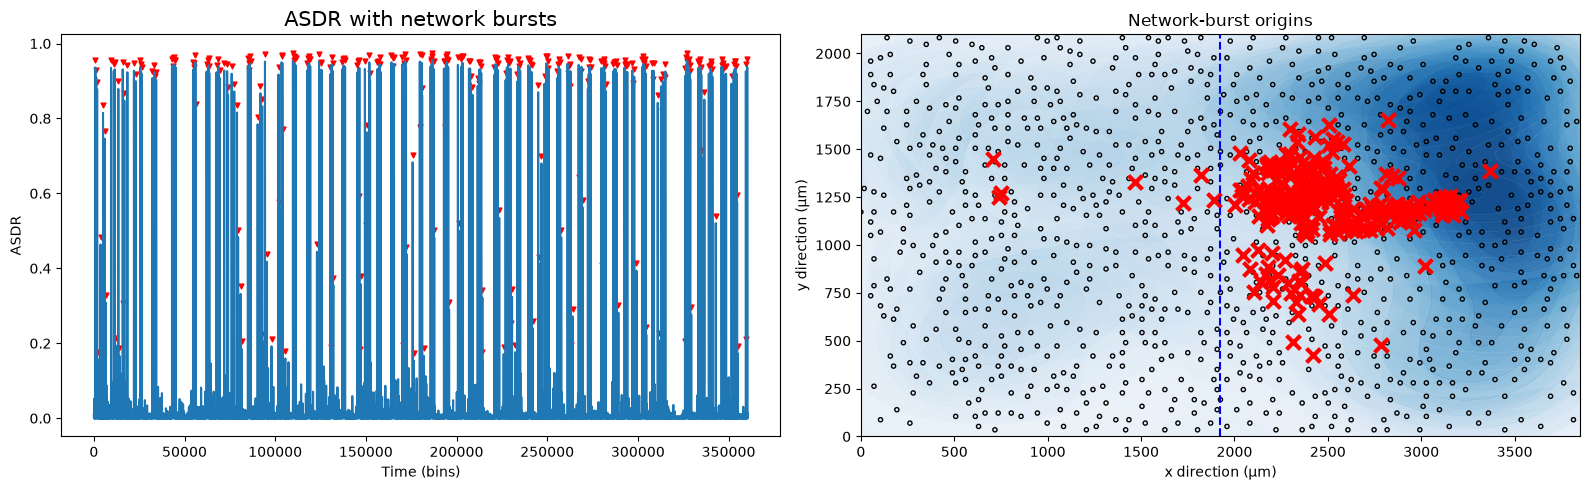

In [37]:
import matplotlib.pyplot as plt
from mxtreme import visualizations as viz

rec = Recording(0, io.load_preprocessed(npz_path))
burst_df = io.load_burst_data(io._burst_csv_path(config.burst_data_dir, rec)).to_dataframe()

fig, (ax_asdr, ax_mea) = plt.subplots(1, 2, figsize=(16, 5))
viz.plot_bursts_on_asdr(rec, burst_df, ax=ax_asdr, title="ASDR with network bursts") # can pass zoom=(start, stop) as an optional parameter to zoom in on the ASDR plot
viz.plot_origin_heatmap(rec, burst_df, ax=ax_mea, title="Network-burst origins")
plt.tight_layout()
plt.show()